In [1]:
import sys, platform, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent.parent / "src"))
import geopops
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import starsim as ss
import sciris as sc
from measles_geopops import *

# https://www.thestate.com/news/state/south-carolina/article313654527.html

# 4.0 Measles with quarantine

In this notebook, we'll explore the custom measles class and along with four quarantine strategies:
1) Quarantine infected individuals only 
2) Quarantine infected individuals and their "siblings" (i.e, other children in same household)
3) Quarantine infected individuals and all their contacts
3) Closing schools of infected individuals

Measles quarantine lasts [21 days](https://www.thestate.com/news/state/south-carolina/article313654527.html) after a known exposure, and according to [SC DPH](https://dph.sc.gov/news/tuesday-measles-update-dph-reports-89-new-measles-cases-upstate-bringing-outbreak-total-789) there were 557 students quarantined as of 25 Jan 2026.

## 4.1 Custom Measles class
Here's a refresher on how Starsim transmission works from previous notebooks:

For each time step, Starsim knows who the infectious agents are (sources) and who the susceptible agents are (targets). For every contact (i.e., edge) between agents, there is a probability of infection every time step if one of those agents is infectious. To calculate that probability, Starsim scales the base infectiousness of the disease by:
* The source’s relative transmissability
* The target’s relative susceptibility
* The effective transmission strength of that contact (edge_weight)

To decide if a target agent gets infected, Starsim draws a uniform random number between 0 and 1 for that contact.
If the probability is larger than the random draw, that contact is marked as having caused an infection. So, for each time step we have a list of infectious sources and a list of targets who got infected.

When an agent enters a disease state (e.g., Infectious), Starsim samples and stores the future time that agent will transmission out of that state (e.g., using the duration of infection). When that stored time is reached, the agent transitions to the next state (e.g., Recovered).

The custom measles class is called `Measles()` and is stored in `mealses_geopops.py` builds on Starsim's base SIR class stored in the Starsim file `diseases.py`. You can customize diseases in many ways (adding disease compartments or subgroup-specific parameters). Our custom measles class includes:
* A state for Exposed individuals
* Age-dependent relative transmissability and relative susceptability
* Reduced susceptibility for vaccinated individuals
* A custom function to seed infections by age and school

Here are the main disease parameters used in `Measles()`:

| Parameter | Definition | Default value |
| -------- | -------- | -------- | 
| beta | Disease's base infectiousness, scaled by rel_trans, rel_sus, and edge_weight to determine probability of infection | 0.9 |
| dur_exp | Duration of Exposed state (not contagious), drawn from normal distribution | 10.0 |
| dur_inf | Duration of Infecitous state (contagious), drawn from normal distribution | 8.0 |
| vax_eff | Effectiveness of vaccine at reducing susceptibility, scales rel_sus by 1-vax_eff | 0.97 |
| rel_sus_babies | Relative susceptability of ages <2 | 1.0 |
| rel_sus_young | Relative susceptability of ages 2-4 | 1.0 |
| rel_sus_school | Relative susceptability of ages 5-18 | 1.0 |
| rel_sus_adults | Relative susceptability of ages >18| 0.0 |
| rel_trans_babies | Relative transmissibility of ages <2 | 1.0 |
| rel_trans_young | Relative transmissibility of ages 2-4 | 1.0 |
| rel_trans_school | Relative transmissibility of ages 5-18 | 1.0 |
| rel_trans_adults | Relative transmissibility of ages >18| 0.0 |

[Hopkins Medicine](https://www.hopkinsmedicine.org/health/conditions-and-diseases/measles-what-you-should-know#:~:text=Nine%20out%20of%2010%20unimmunized,room%20if%20they%20are%20unimmunized.) reports 9 out of 10 unimmunized children will contract the virus if they come into contact with an infected individual. So we set the base infectiousness, beta, to be 0.9. The probability of infection for an exposed *unimunized* 5 year old in our model is therefore 0.9. And the probability of infection for an exposed *imunized* 5 year old is 0.027.
* Unimunized: beta * rel_sus_school * rel_trans_school * edge_weight equals 0 (0.9 * 1 * 1 * 1 = 0.9()
* Imunized: beta * rel_sus_school * (1 - vax_eff) * rel_trans_school * edge_weight equals 0.027 (0.9 * 1 * (1 - 0.97) * 1 * 1 = 0.027)

The [CDC](https://www.cdc.gov/measles/hcp/communication-resources/clinical-diagnosis-fact-sheet.html#:~:text=Measles%20is%20a%20highly%20contagious%20respiratory%20virus,more%20than%20104%C2%B0%20F%20when%20rash%20appears) describes the following progression of illness, which informs dur_exp and dur_inf in the model.

| Measles progression | Days | Model compartment |
| -------- | -------- | -------- | 
| Incubation, no symptoms | 1-10 | Exposed |
| Prodromal symptoms, cough/fever | 11-14 | Infectious |
| Rash | 15-18 | Infectious |
| Rash clears |19-21 | Recovered |

To simplify the Spartanburg example, we also assume
* Only children under 18 can get infected, so we set rel_sus_adults=0 and rel_trans_adults=0
* Infections only occur in the home and at school so we don't need to include the work and group quarters networks in the sim
* No one dies from measles, probability of death is 0

Initial prevalence is defined with a custom seeding function stored in `measles_geopops.py`. [Two schools](https://dph.sc.gov/news/measles-update-dph-confirms-locations-spartanburg-county-outbreak-media-briefing-take-place) in Spartanburg confirmed measles cases in the beginning of October 2025. One of these schools is a private school, and GeoPops currently only has public schools. So the custom seeding function explained in `4_measles_seeding.ipynb` seeds 10 initial infections to students in this public school (Fairforest Elementary). This is built in to the Measles() class and won't be adjusted in this notebook. But you can play around with targeting different schools or changing the number of seed infections in the previous notebook.

This notebook focuses on testing quarantine strategies:
1) Quarantining infected individual only
2) Quarantining infected individual and siblings
3) Closing the entire school of an infected individual
 
The next cell defines sim1 (no quarantine). You can try changing parameter values to see how they impact infection curves.

In the plots, "Infectious" refers to the number of agents currently in the Infectious state (I), and "cumulative infections" means the cumulative sum of new infections.

In [2]:
# Load the people object
ppl = ss.load('data/pop_export/starsim/ppl_vax.pkl')

# Define the networks with edge weights
# Default assumes same relative edge weights, but you can change this
h = geopops.ForStarsim.GPNetwork(name='homenet', edge_weight=1.0) 
s = geopops.ForStarsim.GPNetwork(name='schoolnet', edge_weight=1.0)

measles_pars = sc.objdict(beta      = 0.9, # disease's base infectiousness (scaled by rel_trans, rel_sus, and edge_weight)
                          dur_exp   = ss.normal(10.0), # duration of Exposed state, in this model not infectious, drawn from normal distribution, default=10
                          dur_inf   = ss.normal(8.0), # duration of Infectious state, drawn from normal distribution, default=8
                          vax_eff   = 0.97, # effectiveness of vaccine, scales rel_sus by 1-vax_eff, default=0.97
                          rel_sus_babies   = 1.0, # relative susceptability of ages <2, default=1
                          rel_sus_young    = 1.0, # relative susceptability of ages 2-4, default=1
                          rel_sus_school   = 1.0, # relative susceptability of ages 5-17, default=1
                          rel_sus_adults   = 0.0, # relative susceptability of ages >18, default=0
                          rel_trans_babies = 1.0, # relative transmissability of ages <2, default=1
                          rel_trans_young  = 1.0, # relative transmissability of ages 2-4, default=1
                          rel_trans_school = 1.0, # relative transmissability of ages 5-17, default=1
                          rel_trans_adults = 0.0, # relative transmissability of ages >18, default=0
                          )

Network csv files created and saved successfully


Initializing sim with 357235 agents


/Users/Alisa/venvs/geopops-local/lib/python3.12/site-packages/numba/cpython/hashing.py:477: UserWarning: FNV hashing is not implemented in Numba. See PEP 456 https://www.python.org/dev/peps/pep-0456/ for rationale over not using FNV. Numba will continue to work, but hashes for built in types will be computed using siphash24. This will permit e.g. dictionaries to continue to behave as expected, however anything relying on the value of the hash opposed to hash as a derived property is likely to not work as expected.
  warnings.warn(msg)


  Running 0.0 ( 0/301) (0.00 s)  ———————————————————— 0%
  Running 10.0 (10/301) (0.96 s)  ———————————————————— 4%
  Running 20.0 (20/301) (1.85 s)  •——————————————————— 7%
  Running 30.0 (30/301) (2.82 s)  ••—————————————————— 10%
  Running 40.0 (40/301) (3.96 s)  ••—————————————————— 14%
  Running 50.0 (50/301) (4.91 s)  •••————————————————— 17%
  Running 60.0 (60/301) (5.85 s)  ••••———————————————— 20%
  Running 70.0 (70/301) (6.77 s)  ••••———————————————— 24%
  Running 80.0 (80/301) (7.71 s)  •••••——————————————— 27%
  Running 90.0 (90/301) (8.72 s)  ••••••—————————————— 30%
  Running 100.0 (100/301) (9.79 s)  ••••••—————————————— 34%
  Running 110.0 (110/301) (10.75 s)  •••••••————————————— 37%
  Running 120.0 (120/301) (11.81 s)  ••••••••———————————— 40%
  Running 130.0 (130/301) (13.01 s)  ••••••••———————————— 44%
  Running 140.0 (140/301) (14.10 s)  •••••••••——————————— 47%
  Running 150.0 (150/301) (15.20 s)  ••••••••••—————————— 50%
  Running 160.0 (160/301) (16.41 s)  ••••••

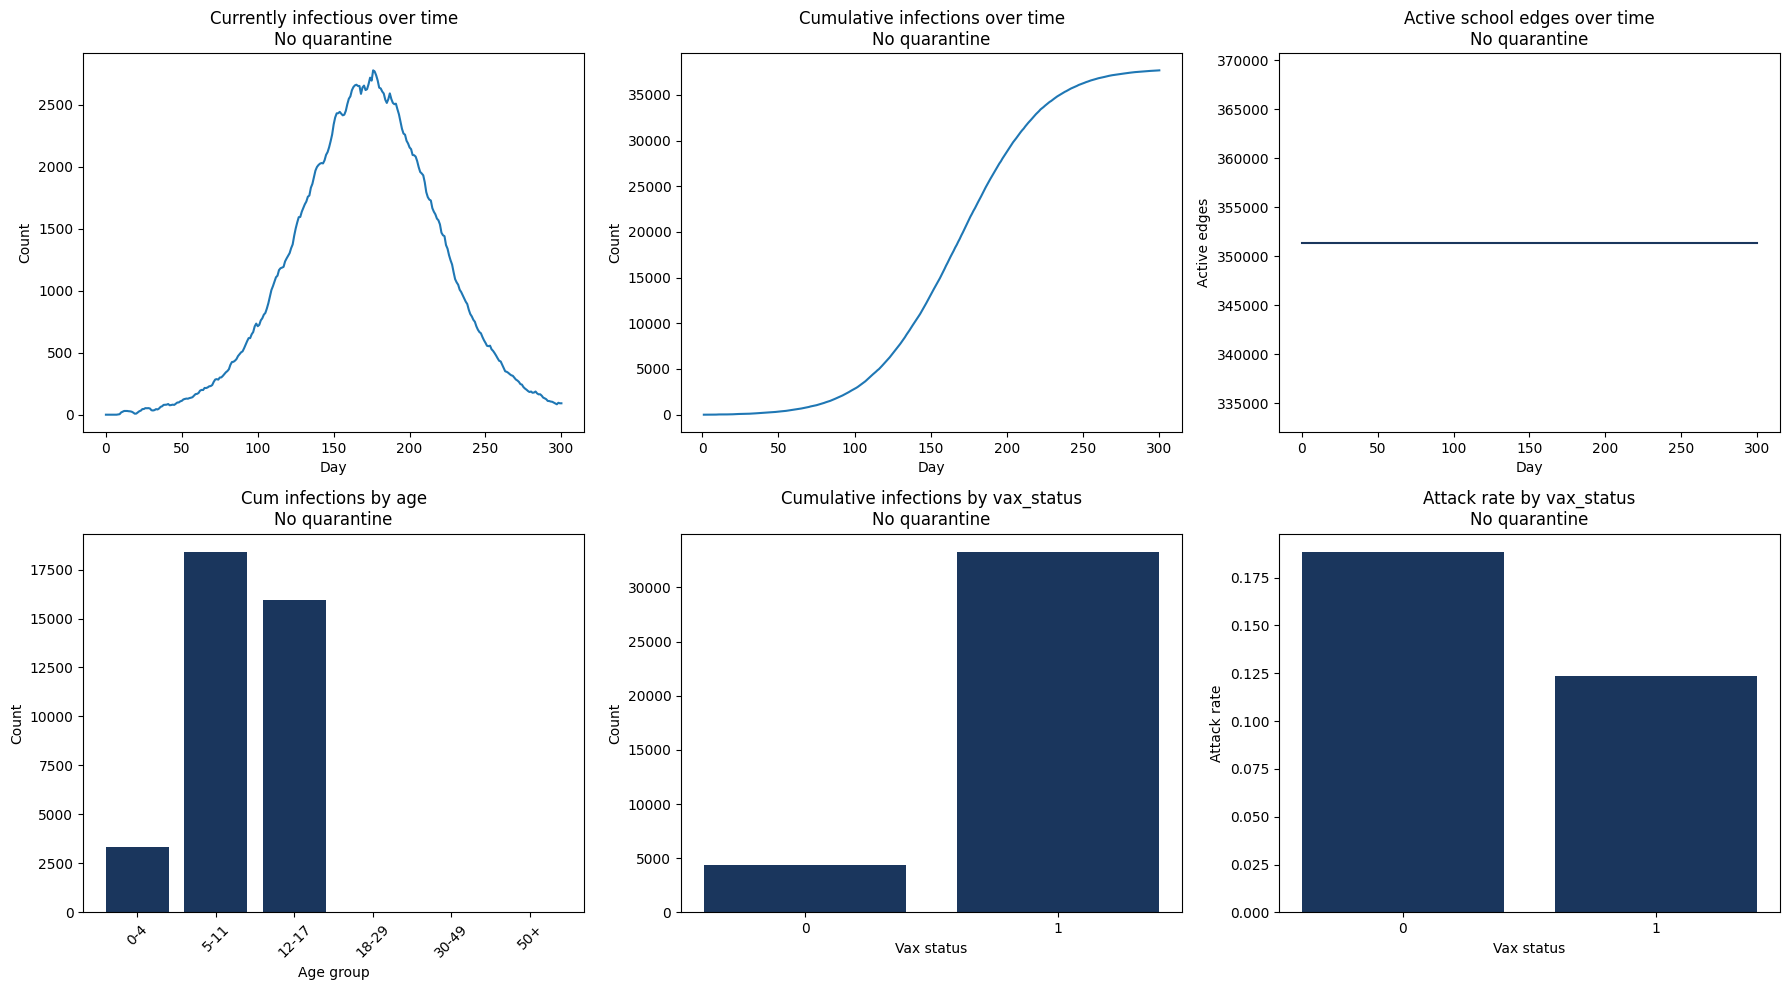

In [3]:
# Run sim with no quarantine
sim1 = ss.Sim(
    pars    = sc.objdict(start = 0, stop  = 300, dt = 1.0),
    people  = ppl,
    networks = [h, s],
    diseases = [Measles(measles_pars)],  # use custom Measles model
    analyzers = ['infection_log']
).run()

# Store results
res1 = sim1.results

# Plot results
plot_measles(sim1, res1, label='No quarantine')

In [4]:
import numpy as np
from collections import Counter

alog = sim1.analyzers['infection_log']

# See which disease logs are available (e.g. ['measles'])
print("infection_log keys:", list(alog.logs.keys()))

# Pick the first disease log (or choose alog.logs['measles'])
log = next(iter(alog.logs.values()))

# Count secondary infections per infector (exclude seed infections where source is NaN)
sec_counts = Counter()
for u, v, data in log.edges(data=True):
    # seeds have source u = nan (so skip those)
    if isinstance(u, float) and np.isnan(u):
        continue
    sec_counts[u] += 1

R0_est = np.mean(list(sec_counts.values())) if sec_counts else 0.0
print("Estimated R0:", R0_est)
print("# infectors counted:", len(sec_counts))

infection_log keys: ['measles']
Estimated R0: 1.696668012018476
# infectors counted: 22299


## 4.2 Quarantine infectious only
It's unlikely that no one would quarantine during a measles outbreak. In this section, we'll simulate quarantining the infected individual only. Probably their contacts would also quarantine, but we'll simulate this scenario so we can compare it to other strategies later. 

`measles_geopops.ipynb` includes a custom Intervention class called `Quarantine_inf()`. It's meant to simulate a scenario where only infectious individuals quarantine. Here's the logic and input parameters:

* The proportion of infected individuals who comply with quarantine is set with `compliance`
* On each timestep, identify agents who are currently in the infectious state
* If the time since they got infected is beyond `days_since_infectious`, they start to "quarantine"
* This means their edges in the school network will be turned "off" (i.e., set to 0) until `dur_quarantine` passes

Any school edge where either endpoint is a quarantining agent has its edge weight set to 0 (removing those school contacts for that day). Edge weights are set back to one when both contacts are no longer in quarantine. The cell below defines the Quarantine_inf() intervention inside the sim. Try changing the inputs of Quarantine_inf() and run the cell to plot results.

Initializing sim with 357235 agents
  Running 0.0 ( 0/301) (0.00 s)  ———————————————————— 0%
  Running 10.0 (10/301) (0.77 s)  ———————————————————— 4%
  Running 20.0 (20/301) (1.86 s)  •——————————————————— 7%
  Running 30.0 (30/301) (2.83 s)  ••—————————————————— 10%
  Running 40.0 (40/301) (3.84 s)  ••—————————————————— 14%
  Running 50.0 (50/301) (4.86 s)  •••————————————————— 17%
  Running 60.0 (60/301) (6.00 s)  ••••———————————————— 20%
  Running 70.0 (70/301) (6.96 s)  ••••———————————————— 24%
  Running 80.0 (80/301) (7.98 s)  •••••——————————————— 27%
  Running 90.0 (90/301) (8.97 s)  ••••••—————————————— 30%
  Running 100.0 (100/301) (10.01 s)  ••••••—————————————— 34%
  Running 110.0 (110/301) (10.95 s)  •••••••————————————— 37%
  Running 120.0 (120/301) (11.98 s)  ••••••••———————————— 40%
  Running 130.0 (130/301) (12.95 s)  ••••••••———————————— 44%
  Running 140.0 (140/301) (14.01 s)  •••••••••——————————— 47%
  Running 150.0 (150/301) (15.08 s)  ••••••••••—————————— 50%
  Runn

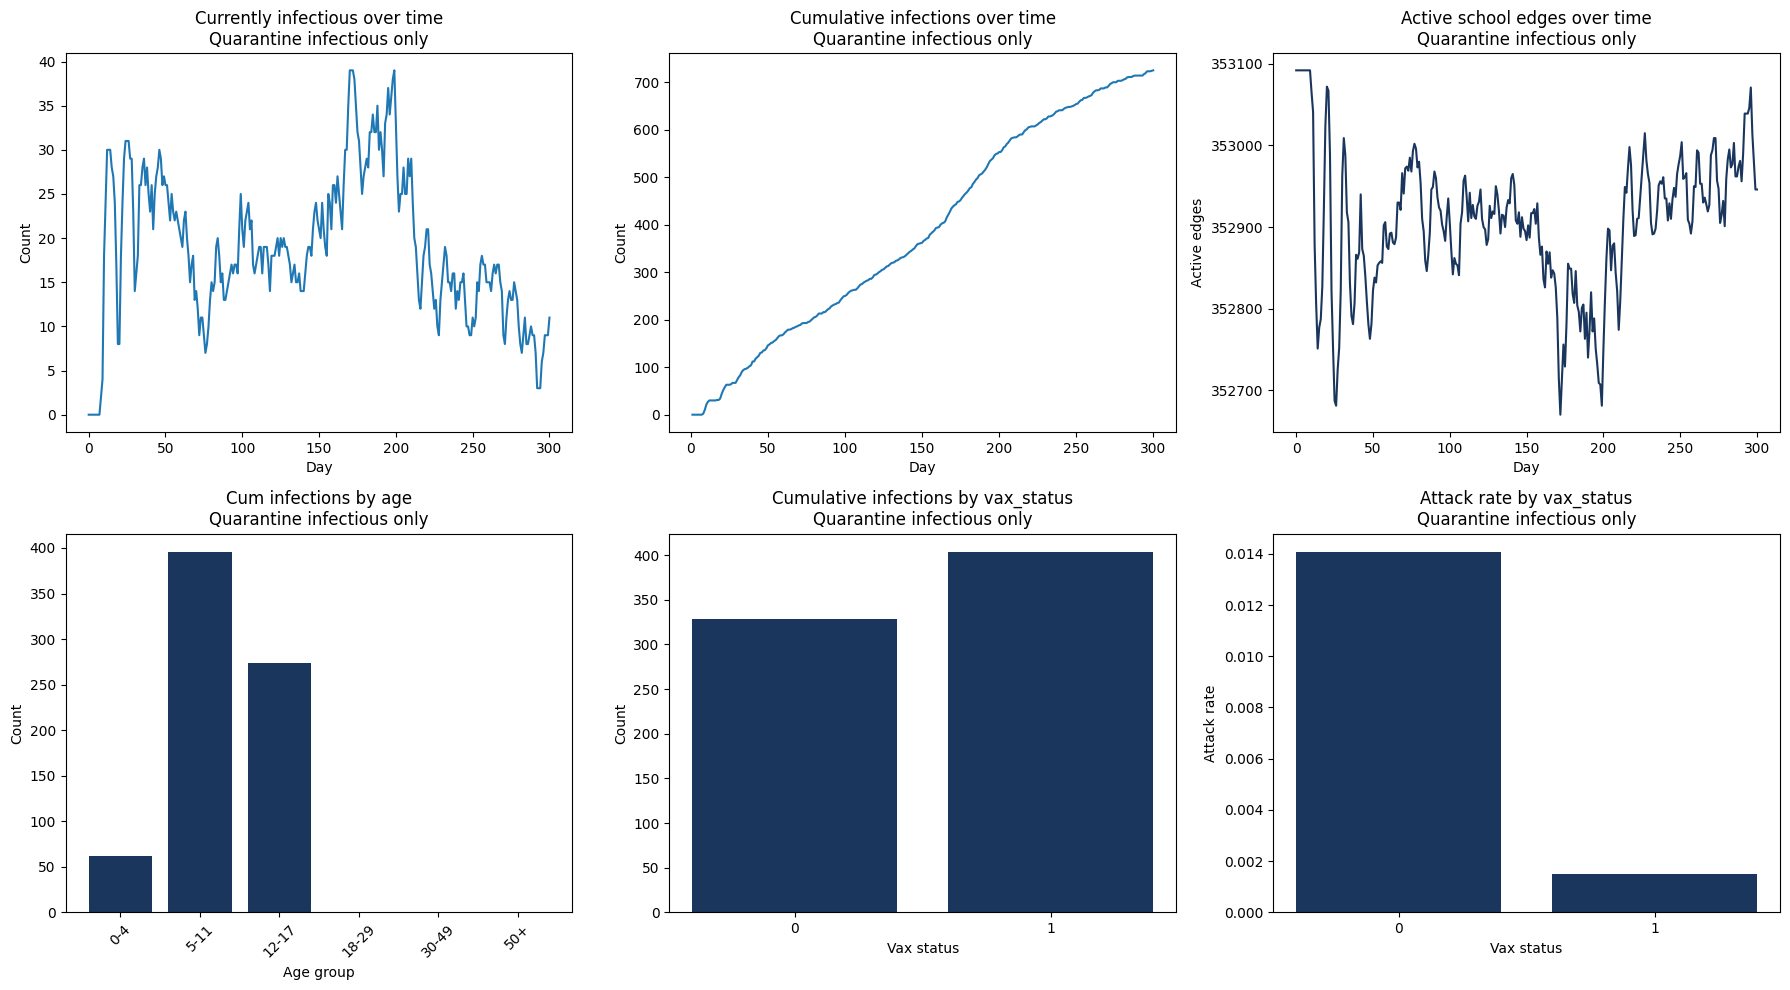

In [5]:
# Run Measles model with Quarantine infected only intervention
sim2 = ss.Sim(
    pars    = sc.objdict(start = 0, stop  =300, dt = 1.0),
    people  = ppl,
    networks = [h, s],
    diseases = [Measles(measles_pars)],
    ############################## SET QUARANTINE PARAMETERS HERE ##############################
    interventions = Quarantine_inf(days_since_infectious=2, # How many days after becoming infectious do people start quarantining? default=3
                                   dur_quarantine=21, # How many days do people quarantine for? default=5
                                   compliance=1.0), # What proportion of infected individuals comply with quarantine? default=1
).run()

# Store results
res2 = sim2.results

# Plot results
plot_measles(sim2, res2, label='Quarantine infectious only')

## 4.3 Quarantine infectious and siblings
Now let's see what happens if siblings also quarantine with the infected individual. There is a custom `Quarantine_sib()` Intervention class in `measles_geopops.py`. It has the same input arguments as before (compliance, days_since_infectious, dur_quarantine) as well as a new one, `children_df`, which is a dataframe of children with their uids, household ids, sch_code, and age. This is so the class can look up other children from the same household as the infected agent. Here's the logic:
* On each timestep, find infectious agents and their siblings by referencing the household id in `children_df`
* If the time since they became infected is at least `days_since_infectious` (and still within the `dur_quarantine` window), they “quarantine” 
* This means turning "off" school-network edges (setting edge_weight to 0) for all quarantining agents
* The proportion of siblings who comply with quarantine is set with `compliance`
* The index infectious agent always quarantines

First, define `children_df`. The `get_children()` function is also stored in `measles_geopops.py`.

In [6]:
# Define children_df
children_df = get_children(ppl)
children_df

Initializing sim with 357235 agents


,uid,household,sch_code,age
0,46267,4,450351001000,17.0
1,155625,5,0,2.0
2,76508,5,0,2.0
3,283591,5,0,4.0
4,42702,10,450351001669,8.0
...,...,...,...,...
68610,180998,116639,450360001018,6.0
68611,259988,116639,450360000209,10.0
68612,188475,116640,450360000209,11.0
68613,91337,116645,0,2.0


Define a new sim with the intervention `Quarantine_sib()` and plot results.

Initializing sim with 357235 agents
  Running 0.0 ( 0/301) (0.00 s)  ———————————————————— 0%
  Running 10.0 (10/301) (0.70 s)  ———————————————————— 4%
  Running 20.0 (20/301) (1.68 s)  •——————————————————— 7%
  Running 30.0 (30/301) (2.65 s)  ••—————————————————— 10%
  Running 40.0 (40/301) (3.77 s)  ••—————————————————— 14%
  Running 50.0 (50/301) (4.88 s)  •••————————————————— 17%
  Running 60.0 (60/301) (5.92 s)  ••••———————————————— 20%
  Running 70.0 (70/301) (6.92 s)  ••••———————————————— 24%
  Running 80.0 (80/301) (7.93 s)  •••••——————————————— 27%
  Running 90.0 (90/301) (8.99 s)  ••••••—————————————— 30%
  Running 100.0 (100/301) (10.10 s)  ••••••—————————————— 34%
  Running 110.0 (110/301) (11.05 s)  •••••••————————————— 37%
  Running 120.0 (120/301) (12.09 s)  ••••••••———————————— 40%
  Running 130.0 (130/301) (13.12 s)  ••••••••———————————— 44%
  Running 140.0 (140/301) (14.25 s)  •••••••••——————————— 47%
  Running 150.0 (150/301) (15.32 s)  ••••••••••—————————— 50%
  Runn

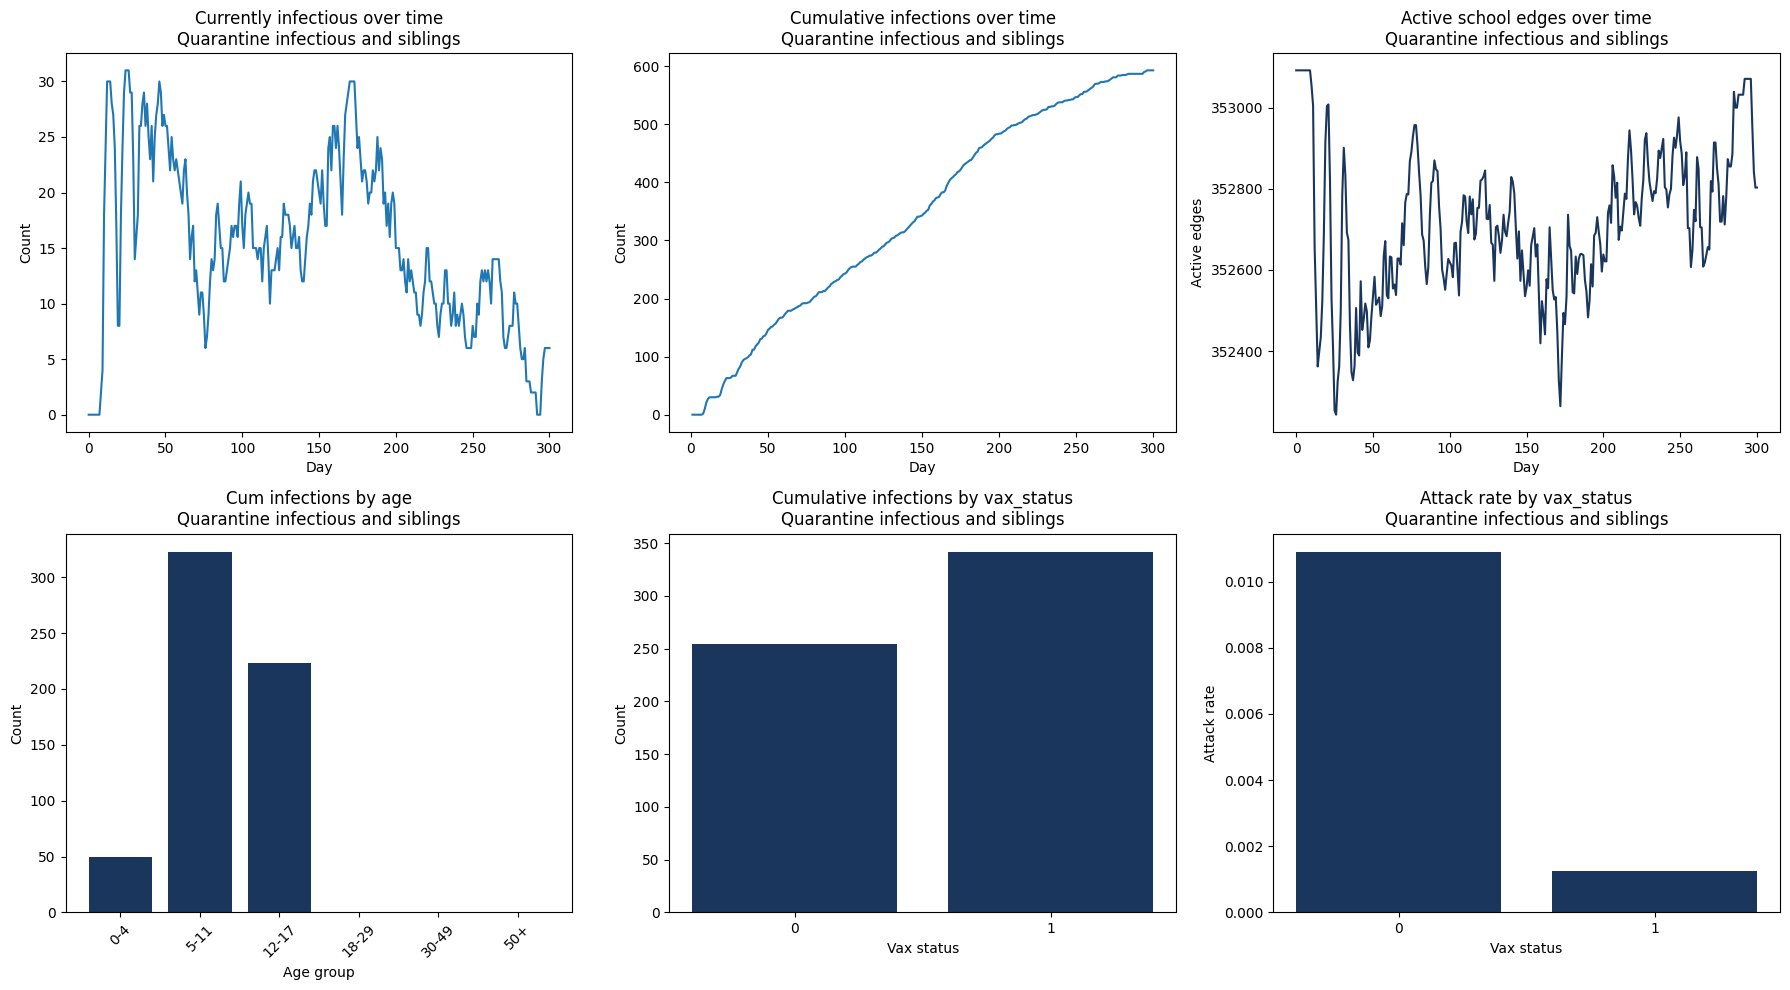

In [7]:
# Run Measles model with Quarantine siblings intervention
sim3 = ss.Sim(
    pars    = sc.objdict(start = 0, stop  =300, dt = 1.0),
    people  = ppl,
    networks = [h, s],
    diseases = [Measles(measles_pars)],
    ############################## SET QUARANTINE PARAMETERS HERE ##############################
    interventions = [Quarantine_sib(days_since_infectious=2, # How many days after becoming infectious do people start quarantining?
                                   days_quarantine=21, # How many days do people quarantine for?
                                   compliance=1.0, # What proportion of infected individuals comply with quarantine?
                                   children_df=children_df)], # Need dataframe of children by household
).run()

# Store results
res3 = sim3.results

# Plot results
plot_measles(sim3, res3, label='Quarantine infectious and siblings')

## 4.4 Quarantine contacts
The Quarantine contacts scenario is probably most realistic and comparable to contact tracing. It simulates quarantining an infectious individual and all of their contacts at home and at school. Here's the logic:

* Identify infectious individuals and their contacts at home and at school by references household id and sch_code in `children_df`
* If `days_since_infectious` has passed, mark these agents as quarantining until `dur_quarantine` passes
* While quarantined, remove set the edge_weight of their contacts in the school network to 0
* The proportion of contacts who comply with quarantine is set with `compliance`
* The index infectious agent always quarantines

This class is called `Quarantine_contacts()` and is stored in `measles_geopops.py`. 

Initializing sim with 357235 agents
  Running 0.0 ( 0/301) (0.00 s)  ———————————————————— 0%
  Running 10.0 (10/301) (0.69 s)  ———————————————————— 4%
  Running 20.0 (20/301) (1.55 s)  •——————————————————— 7%
  Running 30.0 (30/301) (2.45 s)  ••—————————————————— 10%
  Running 40.0 (40/301) (3.50 s)  ••—————————————————— 14%
  Running 50.0 (50/301) (4.60 s)  •••————————————————— 17%
  Running 60.0 (60/301) (5.64 s)  ••••———————————————— 20%
  Running 70.0 (70/301) (6.75 s)  ••••———————————————— 24%
  Running 80.0 (80/301) (7.75 s)  •••••——————————————— 27%
  Running 90.0 (90/301) (8.73 s)  ••••••—————————————— 30%
  Running 100.0 (100/301) (9.66 s)  ••••••—————————————— 34%
  Running 110.0 (110/301) (10.53 s)  •••••••————————————— 37%
  Running 120.0 (120/301) (11.46 s)  ••••••••———————————— 40%
  Running 130.0 (130/301) (12.40 s)  ••••••••———————————— 44%
  Running 140.0 (140/301) (13.29 s)  •••••••••——————————— 47%
  Running 150.0 (150/301) (14.25 s)  ••••••••••—————————— 50%
  Runni

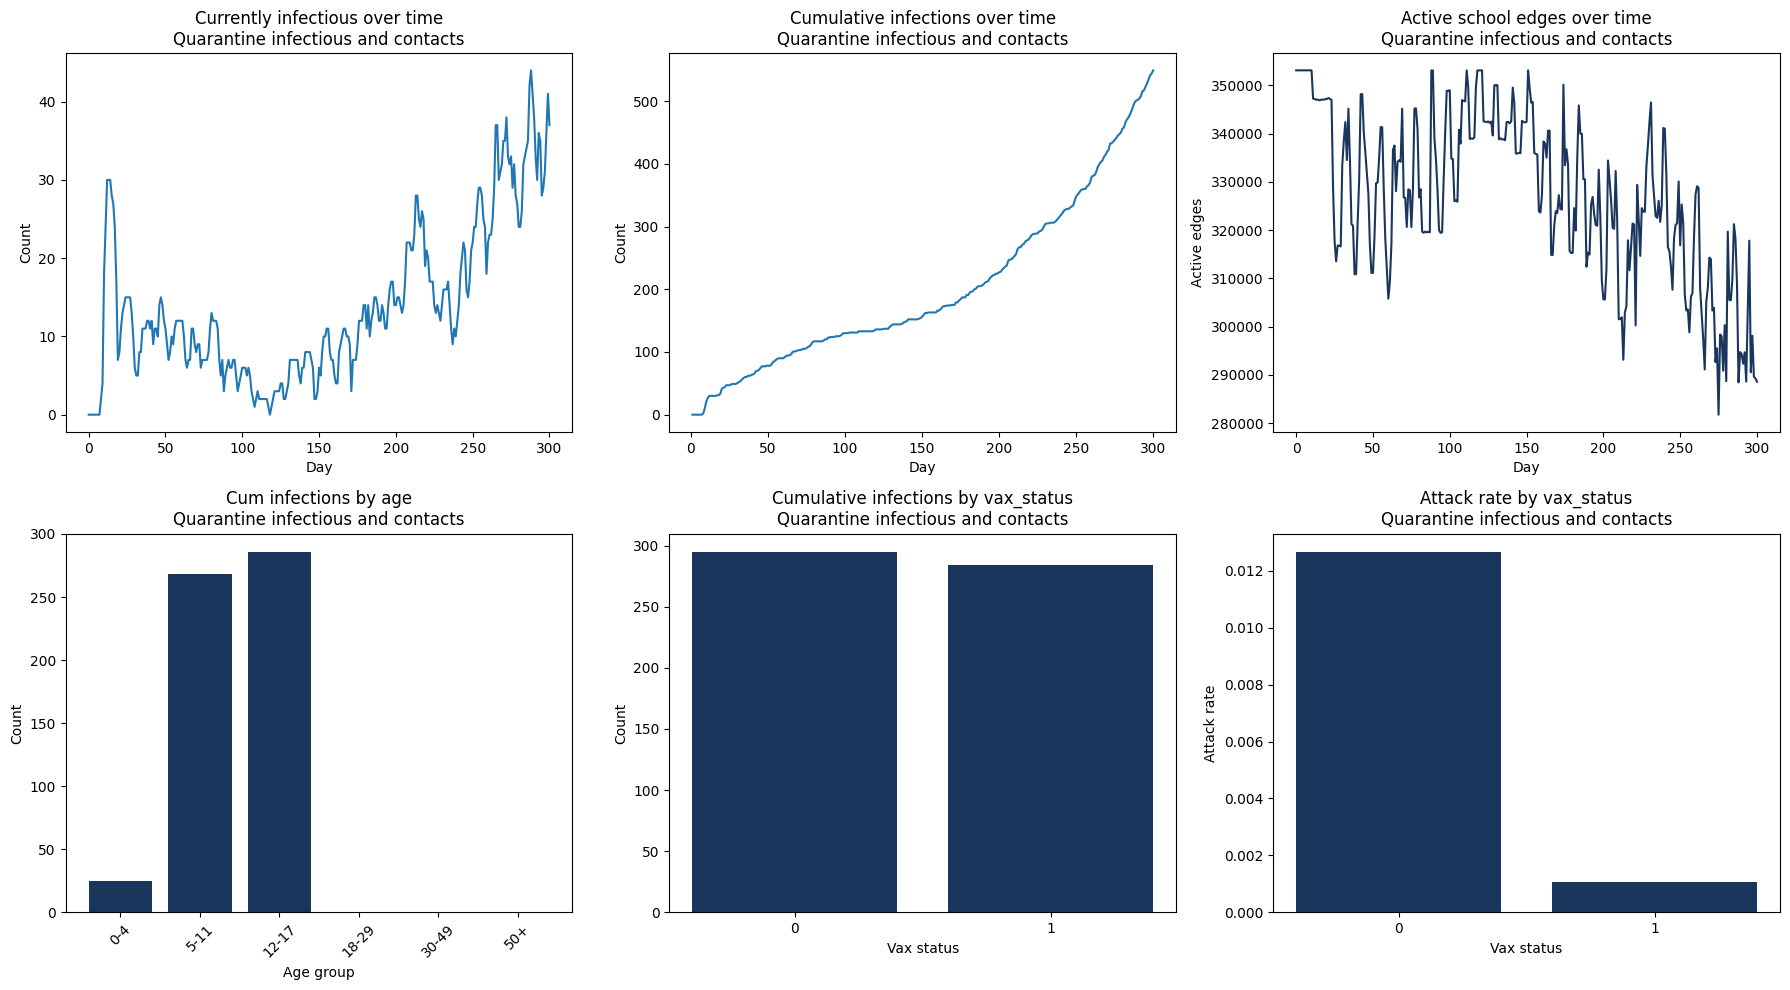

In [8]:
# Run Measles model with with Quarantine contacts intervention
sim4 = ss.Sim(
    pars    = sc.objdict(start = 0, stop  =300, dt = 1.0),
    people  = ppl,
    networks = [h, s],
    diseases = [Measles(measles_pars)],
    ############################## SET QUARANTINE PARAMETERS HERE ##############################
    interventions = [Quarantine_contacts(days_since_infectious=3, # How many days after becoming infectious do people start quarantining?
                                         dur_quarantine=21, # How many days do people quarantine for?
                                         compliance=0.7, # What proportion of infected individuals comply with quarantine?
                                         children_df=children_df)], # Need dataframe of children by household
).run()

# Store results
res4 = sim4.results

# Plot results
plot_measles(sim4, res4, label='Quarantine infectious and contacts')

## 4.5 Close school of infectious
This intervention simulates closing the entire school of an infectious individual. Because all GeoPops and Starsim code is open source, AI-coding assistants can be super helpful in designing your own interventions. Here's the prompt I used to make a "Close Schools" intervention that removes the school edges of all the agents in the same school as an infectious agent. It uses the same `days_since_infectious` and `days_quarantine` inputs. There is no `compliance`, input assuming that a school will definitely close if there is an infectious individual detected. 

**Prompt:** Read @4_measles_quarantine.ipynb. The dataframe children_df lists all children uids, household id, and sch_id. I want to make a new ss.Intervention class called CloseSchools() which deactivates the edges of all the children in the same school as an infected individual. It will have the same input arguments of days_since_infectious and days_quarantine. Print suggested code in chat.

I copy and pasted the code below. It worked on the first try! But I had to add the lists for tracking the number of quarantined and active school edges over tiem. I also changed it so that the edge_weights were not hardcoded as 1 but used the edge_weights in from networks. 

In [ ]:
class CloseSchools(ss.Intervention):
    def __init__(self, *args,
                 days_since_infectious=1,
                 days_quarantine=7,
                 children_df=None,
                 **kwargs):
        """
        Close entire schools for a fixed window after any student becomes infectious.

        Args:
            days_since_infectious: offset (in days) after infection when school closure starts
            days_quarantine: duration (in days) that affected schools remain closed
            children_df: DataFrame with at least ['uid', 'sch_code'] for school-attending agents
        """
        super().__init__(*args, **kwargs)
        self.days_since_infectious = days_since_infectious
        self.days_quarantine = days_quarantine
        self.children = children_df  # uid, household, sch_code (uid as int)

        # Tracking
        self.school_edges = []          # number of active school edges per day
        # Number of students quarantined each day (i.e., students attending schools that are closed today)
        # Kept for compatibility with notebook plots.
        self.quarantined = []
        self.closed_schools = []        # list of sets of closed schools per day (optional)

        # Internal: map uid -> school id, and school id -> student uids
        self._uid_to_school = None
        self._school_to_uids = None
        self._school_closed_until = {}  # sch_code -> day (float) until which it remains closed
        self._beta0 = None               # baseline school network edge weights

    def init_pre(self, sim):
        super().init_pre(sim)
        if self.children is None:
            raise RuntimeError("CloseSchool requires children_df with columns ['uid', 'sch_code'].")

        df = self.children.copy()
        df = df.dropna(subset=['sch_code'])
        df['uid'] = df['uid'].astype(int)
        df['ssch_codeh_id'] = df['sch_code'].astype(int)

        # uid -> sch_code
        self._uid_to_school = dict(zip(df['uid'].values, df['sch_code'].values))

        # sch_code -> np.ndarray of uids
        self._school_to_uids = {
            sch: grp['uid'].to_numpy(dtype=int)
            for sch, grp in df.groupby('sch_code')
        }

        # Snapshot baseline edge weights so we can restore them each step
        net = sim.networks['schoolnet']
        self._beta0 = net.edges.beta.copy()
        return

    def step(self):
        sim = self.sim
        net = sim.networks['schoolnet']
        ti = sim.ti

        # Shortcuts to network arrays
        p1 = net.edges.p1
        p2 = net.edges.p2
        beta = net.edges.beta

        # Restore baseline before applying any school closure edge changes
        if self._beta0 is None:
            self._beta0 = beta.copy()
        beta[:] = self._beta0

        # --- 1) Update which schools should be closed based on current infections ---

        infected = sim.people.measles.infected
        ti_infected = sim.people.measles.ti_infected
        days_since_infected = ti - ti_infected

        # Base infectious students in the quarantine window
        base_quarantined = (
            infected
            & (days_since_infected >= self.days_since_infectious)
            & (days_since_infected < self.days_since_infectious + self.days_quarantine)
        )
        base_uids = ss.uids(base_quarantined)  # Starsim UIDs

        # For any such infected student with a known school, extend that school’s closure window
        if len(base_uids):
            for uid in base_uids:
                uid_int = int(uid)
                sch_code = self._uid_to_school.get(uid_int, None)
                if sch_code is None:
                    continue
                # Close this school until (ti + days_quarantine) at least
                current_until = self._school_closed_until.get(sch_code, -np.inf)
                self._school_closed_until[sch_code] = max(current_until, ti + self.days_quarantine)

        # --- 2) Determine which schools are closed on this day ---

        closed_schools_today = {
            sch for sch, t_until in self._school_closed_until.items() if ti < t_until
        }

        # Optionally record closed school set
        self.closed_schools.append(closed_schools_today.copy())

        # --- 3) Compute which UIDs are in closed schools today ---

        if closed_schools_today:
            # Union of all student UIDs for closed schools
            closed_uids_list = [
                self._school_to_uids[sch]
                for sch in closed_schools_today
                if sch in self._school_to_uids
            ]
            if closed_uids_list:
                closed_uids = np.unique(np.concatenate(closed_uids_list))
            else:
                closed_uids = np.empty(0, dtype=int)
        else:
            closed_uids = np.empty(0, dtype=int)

        # --- 3b) Track quarantined students today ---
        self.quarantined.append(int(closed_uids.size))

        # --- 4) Apply closure to the school network edges ---

        if closed_uids.size > 0:
            mask_disable = np.isin(p1, closed_uids) | np.isin(p2, closed_uids)
        else:
            mask_disable = np.zeros(len(p1), dtype=bool)

        beta[mask_disable] = np.zeros_like(beta[mask_disable])

        # --- 5) Track active school edges ---

        self.school_edges.append(int(np.count_nonzero(beta)))
        return


Now pass this into the sim and run.

Initializing sim with 357235 agents
  Running 0.0 ( 0/301) (0.00 s)  ———————————————————— 0%
  Running 10.0 (10/301) (0.70 s)  ———————————————————— 4%
  Running 20.0 (20/301) (1.54 s)  •——————————————————— 7%
  Running 30.0 (30/301) (2.42 s)  ••—————————————————— 10%
  Running 40.0 (40/301) (3.30 s)  ••—————————————————— 14%
  Running 50.0 (50/301) (4.14 s)  •••————————————————— 17%
  Running 60.0 (60/301) (5.04 s)  ••••———————————————— 20%
  Running 70.0 (70/301) (5.90 s)  ••••———————————————— 24%
  Running 80.0 (80/301) (6.74 s)  •••••——————————————— 27%
  Running 90.0 (90/301) (7.59 s)  ••••••—————————————— 30%
  Running 100.0 (100/301) (8.42 s)  ••••••—————————————— 34%
  Running 110.0 (110/301) (9.27 s)  •••••••————————————— 37%
  Running 120.0 (120/301) (10.10 s)  ••••••••———————————— 40%
  Running 130.0 (130/301) (10.85 s)  ••••••••———————————— 44%
  Running 140.0 (140/301) (11.66 s)  •••••••••——————————— 47%
  Running 150.0 (150/301) (12.44 s)  ••••••••••—————————— 50%
  Runnin

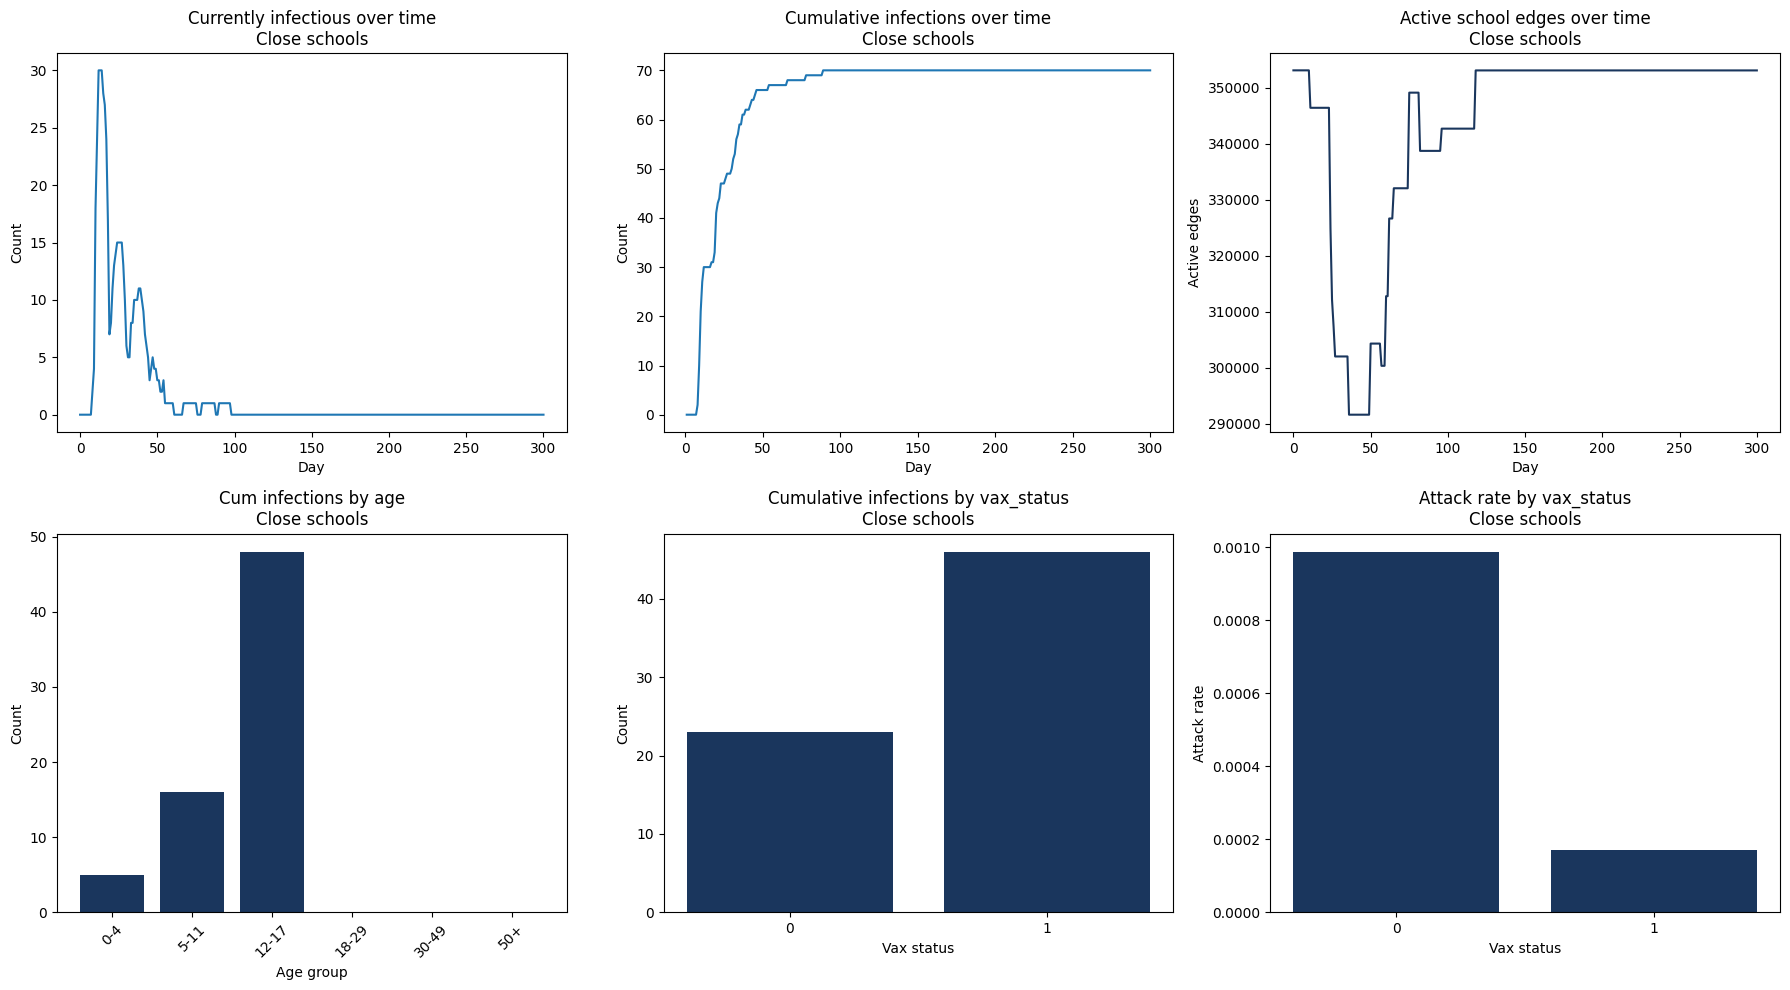

In [10]:
# Run Measles model with CloseSchools intervention
sim5 = ss.Sim(
    pars    = sc.objdict(start = 0, stop  =300, dt = 1.0),
    people  = ppl,
    networks = [h, s],
    diseases = [Measles(measles_pars)],
    ############################## SET QUARANTINE PARAMETERS HERE ##############################
    interventions = [CloseSchools(days_since_infectious=3, # How many days after becoming infectious do people start quarantining?
                                   days_quarantine=21, # How many days do people quarantine for?
                                   children_df=children_df)], # Need dataframe of children by household
).run()

# Store results
res5 = sim5.results

# Plot results
plot_measles(sim5, res5, label='Close schools')

## 4.6 Plot comparisons
Let's plot comparisons of all the quarantine strategies.

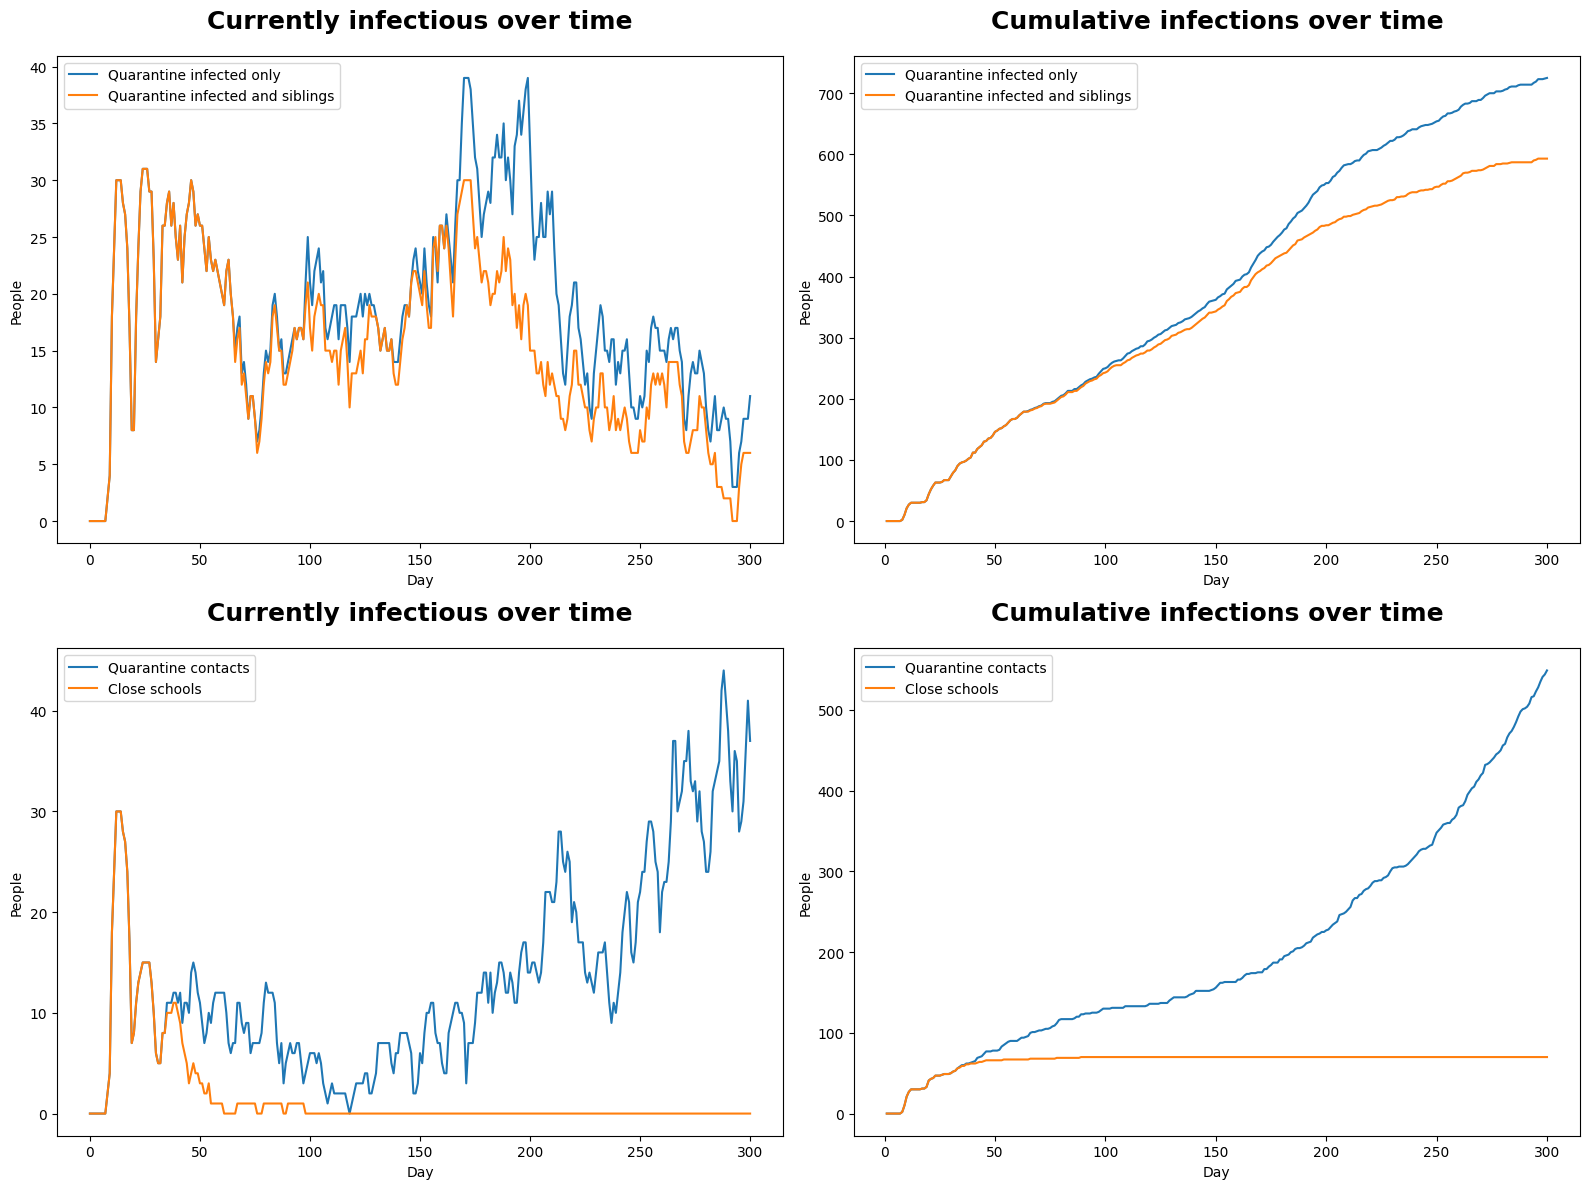

In [11]:
# Infectious and cumulative infections over time of all sims
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()  # <-- make axes 1D

# Left: currently infected over time
ax = axes[0]
ax.plot(res2.timevec, res2.measles.n_infected, label='Quarantine infected only')
ax.plot(res3.timevec, res3.measles.n_infected, label='Quarantine infected and siblings')
ax.set_title('Currently infectious over time', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Day')
ax.set_ylabel('People')
ax.legend()

# Right: cumulative infections over time
ax = axes[1]
ax.plot(res2.timevec[1:], res2.measles.new_infections[1:].cumsum(), label='Quarantine infected only')
ax.plot(res3.timevec[1:], res3.measles.new_infections[1:].cumsum(), label='Quarantine infected and siblings')
ax.set_title('Cumulative infections over time', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Day')
ax.set_ylabel('People')
ax.legend()

# Bottom-left: currently infectious (close schools)
ax = axes[2]
ax.plot(res4.timevec, res4.measles.n_infected, label='Quarantine contacts')
ax.plot(res5.timevec, res5.measles.n_infected, label='Close schools')
ax.set_title('Currently infectious over time', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Day')
ax.set_ylabel('People')
ax.legend()

# Bottom-right: cumulative infections (close schools)
ax = axes[3]
ax.plot(res4.timevec[1:], res4.measles.new_infections[1:].cumsum(), label='Quarantine contacts')
ax.plot(res5.timevec[1:], res5.measles.new_infections[1:].cumsum(), label='Close schools')
ax.set_title('Cumulative infections over time', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Day')
ax.set_ylabel('People')
ax.legend()

fig.tight_layout()
plt.show()

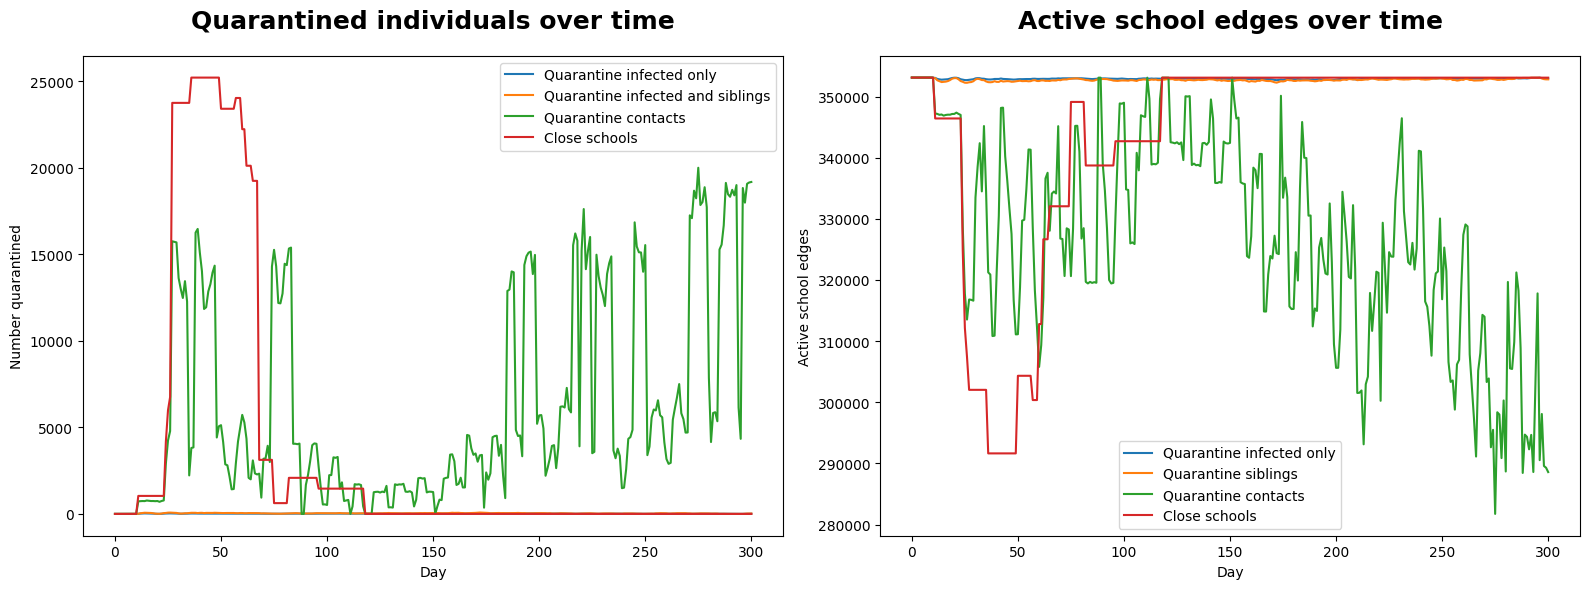

In [12]:
# Quarantined individuals and active school edges over time

q2 = sim2.interventions[0] # Quarantine infected only
q3 = sim3.interventions[0] # Quarantine infected and siblings
q4 = sim4.interventions[0] # Quarantine contacts
q5 = sim5.interventions[0] # Close schools

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Quarantined individuals over time
ax = axes[0]
days_q = sim2.results.timevec[:len(q2.quarantined)]
ax.plot(days_q, q2.quarantined, label='Quarantine infected only')
ax.plot(days_q, q3.quarantined, label='Quarantine infected and siblings')
ax.plot(days_q, q4.quarantined, label='Quarantine contacts')
ax.plot(days_q, q5.quarantined, label='Close schools')
ax.set_xlabel('Day')
ax.set_ylabel('Number quarantined')
ax.set_title('Quarantined individuals over time',fontsize=18, fontweight='bold', pad=20)
ax.legend()

# Right: Active school edges over time
ax = axes[1]
days_e = sim2.results.timevec[:len(q2.school_edges)]
ax.plot(days_e, q2.school_edges, label='Quarantine infected only')
ax.plot(days_e, q3.school_edges, label='Quarantine siblings')
ax.plot(days_e, q4.school_edges, label='Quarantine contacts')
ax.plot(days_e, q5.school_edges, label='Close schools')
ax.set_xlabel('Day')
ax.set_ylabel('Active school edges')
ax.set_title('Active school edges over time',fontsize=18, fontweight='bold', pad=20)
ax.legend()

plt.tight_layout()
plt.show()

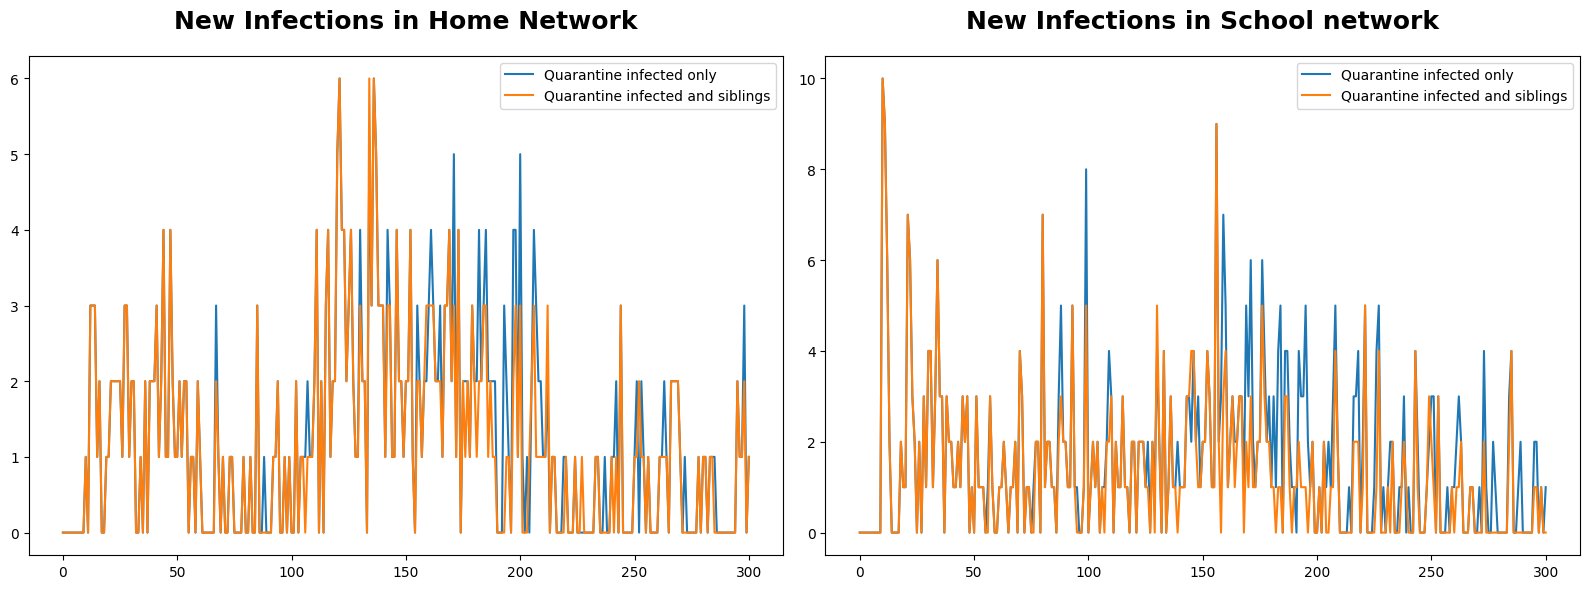

In [13]:
# Infections by network over time

sim2_infs_h = res2['measles'].new_infections_by_network[:, 0]
sim2_infs_s = res2['measles'].new_infections_by_network[:, 1]

sim3_infs_h = res3['measles'].new_infections_by_network[:, 0]
sim3_infs_s = res3['measles'].new_infections_by_network[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Infections in Home
ax = axes[0]
ax.set_title('New Infections in Home Network',fontsize=18, fontweight='bold', pad=20)
ax.plot(res2.timevec, sim2_infs_h, label='Quarantine infected only')
ax.plot(res3.timevec, sim3_infs_h, label='Quarantine infected and siblings')
ax.legend()

# Right: Infections in School
ax = axes[1]
ax.set_title('New Infections in School network',fontsize=18, fontweight='bold', pad=20)
ax.plot(res2.timevec, sim2_infs_s, label='Quarantine infected only')
ax.plot(res3.timevec, sim3_infs_s, label='Quarantine infected and siblings')
ax.legend()

plt.tight_layout()
plt.show()

### Interpreting results
Quarantining siblings doesn't seem to have a huge impact. It mostly removes non‑infectious potential spreaders from school, after the important transmissions have already occurred. The infected child — who is the main “driver” of school transmission — is quarantined in both strategies, so the key school edges are already cut in sim2. By the time you quarantine siblings, many of them have already been infected (or exposed) via home contacts or would never have become major transmitters at school, so taking their school edges away doesn’t substantially change who gets infected overall. That’s why you see many more people quarantined and fewer active school edges in sim3, but nearly identical home/school infection curves and total epidemic size compared with sim2.

You are quarantining siblings at the same calendar time as the infected child (when the index case hits days_since_infectious ≥ d), but that doesn’t mean they’re in the same infection state or that removing their school edges has comparable impact. By the time that shared quarantine trigger fires, (a) the index child has already had a few highly infectious days at school and home, seeding most of their downstream cases, (b) siblings who are going to get infected are often already infected or exposed via intense household contact, and (c) many quarantined siblings are still susceptible and would never have become big transmitters at school even if left there. So you do cut siblings’ school edges at the same time as the index child, but the index child’s edges are the ones carrying most of the “critical” transmission; removing siblings’ edges at that point mostly trims marginal paths, which is why the overall curves barely shift.

According to the model with all its assumptions, closing schools (or moving to remote learning) for a period of time after a student gets infected has more of an impact on the epidemic than quarantining the infected individual only or quarantining the infected individual and their siblings. This makes sense given our assumptions because the simulation starts with 10 infections at one school. 

### What's next?
Obviously, these results do not match the confirm case counts reported by SC DPH. Even though our model has a lot of parameters and is pretty complex, it is a very simplified picture of what's actually going on in a measles outbreak. What factors could be important to incorporate into the model to make scenarios more realistic? Given what you know about how GeoPops and Starsim work together, brainstorm how you would implement these factors into the network and modeling structure. What data would you need?

**Example ideas:**
* Assign immunization rates by school
* Make and after-school activities network